In [ ]:
!pip install shap --quiet

In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
from sklearn.metrics import (accuracy_score,
                             confusion_matrix,
                             classification_report,
                             roc_auc_score,
                             ConfusionMatrixDisplay)

In [ ]:
import shap

In [ ]:
sns.set_style("whitegrid")

In [ ]:
plt.rcParams['figure.dpi'] = 120

In [ ]:
plt.rcParams['font.size'] = 11

In [ ]:
print("=" * 50)
print("  All libraries imported successfully!")
print("=" * 50)

  All libraries imported successfully!


In [ ]:
from google.colab import files
print("A file picker will open. Select your CSV file.")
uploaded = files.upload()

A file picker will open. Select your CSV file.


Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


In [ ]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [ ]:
print(f"Dataset loaded successfully!")


Dataset loaded successfully!


In [ ]:
print(f"Shape: {df.shape[0]} rows (employees) x {df.shape[1]} columns (features)")


Shape: 1470 rows (employees) x 35 columns (features)


In [ ]:
print("First 5 rows of the dataset:")

First 5 rows of the dataset:


In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
print("Column names and data types:")
print(df.dtypes)
print()

Column names and data types:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel          

In [ ]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
print("MISSING VALUES CHECK:")
print("-" * 35)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("Great news! Zero missing values found.")
    print("IBM HR dataset is already perfectly clean.")
else:
    print(missing[missing > 0])

MISSING VALUES CHECK:
-----------------------------------
Great news! Zero missing values found.
IBM HR dataset is already perfectly clean.


In [ ]:
print()
print("DUPLICATE ROWS CHECK:")
print("-" * 35)
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")


DUPLICATE ROWS CHECK:
-----------------------------------
Duplicate rows found: 0


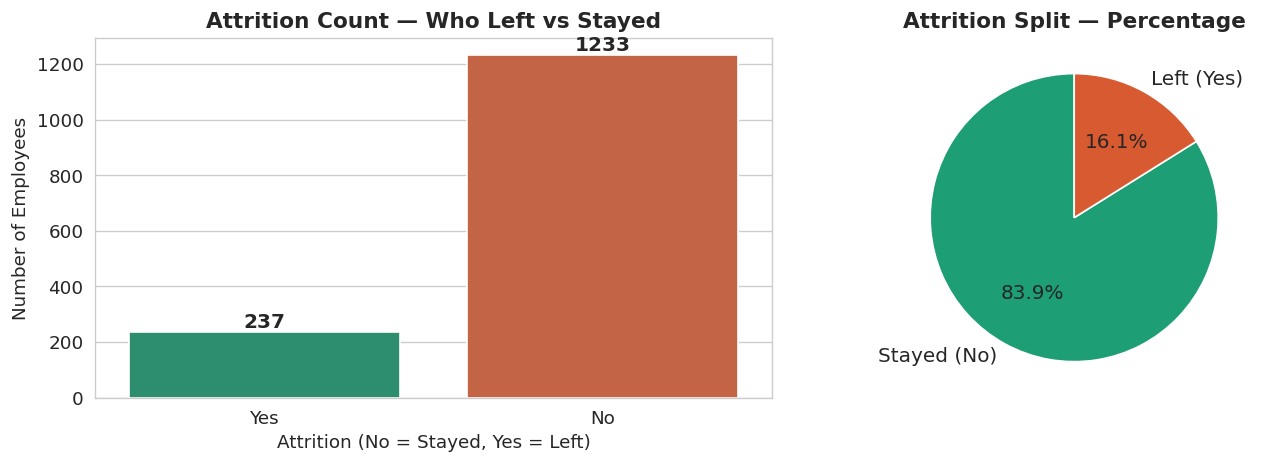

Chart 1 saved: chart1_attrition_overview.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left chart: raw count
sns.countplot(x='Attrition', data=df,
              palette=['#1D9E75', '#D85A30'],
              ax=axes[0])
axes[0].set_title('Attrition Count — Who Left vs Stayed', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Attrition (No = Stayed, Yes = Left)')
axes[0].set_ylabel('Number of Employees')

# Add count labels on top of each bar
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

# Right chart: percentage pie
attrition_counts = df['Attrition'].value_counts()
axes[1].pie(attrition_counts,
            labels=['Stayed (No)', 'Left (Yes)'],
            colors=['#1D9E75', '#D85A30'],
            autopct='%1.1f%%',           # Show percentage on each slice
            startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Attrition Split — Percentage', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('chart1_attrition_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved: chart1_attrition_overview.png")


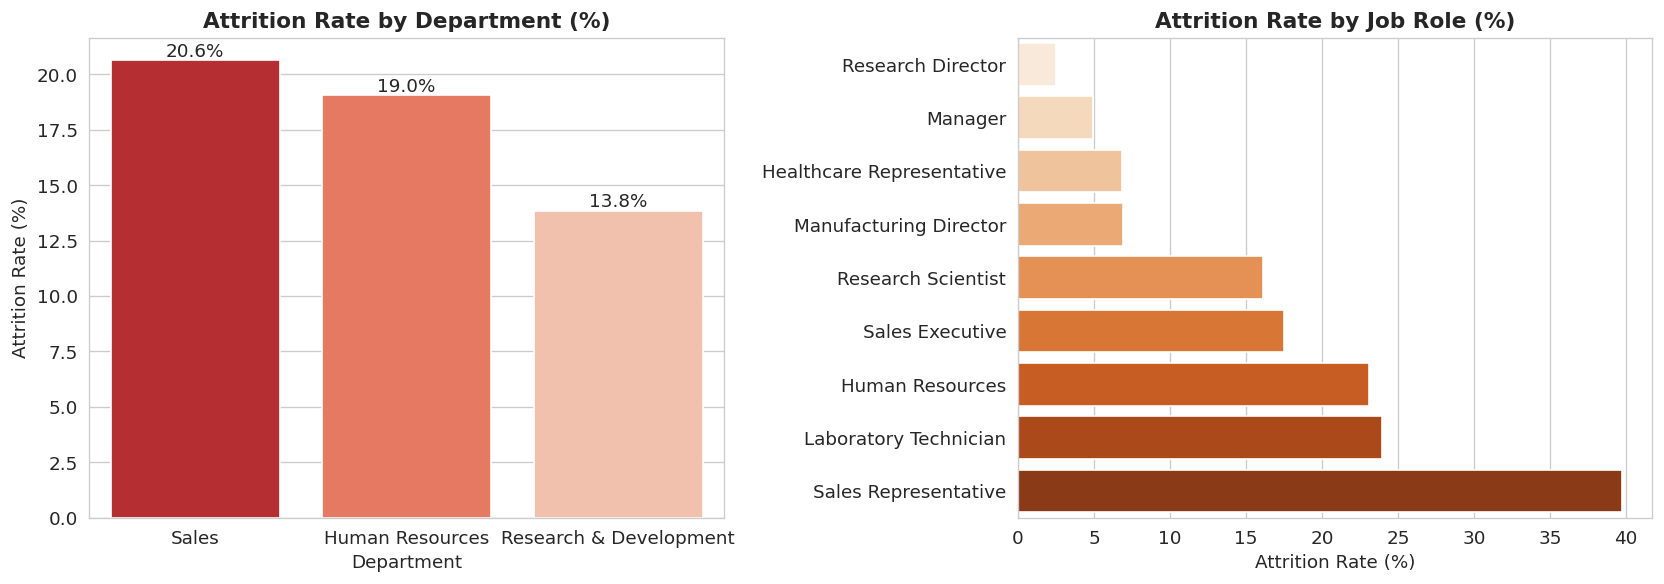

Chart 2 saved: chart2_department_jobrole.png


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Department-wise attrition
dept_attr = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
dept_attr.columns = ['Department', 'AttritionRate']
dept_attr = dept_attr.sort_values('AttritionRate', ascending=False)

sns.barplot(x='Department', y='AttritionRate',
            data=dept_attr, palette='Reds_r', ax=axes[0])
axes[0].set_title('Attrition Rate by Department (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Attrition Rate (%)')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Job Role attrition (top roles)
role_attr = df.groupby('JobRole')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
role_attr.columns = ['JobRole', 'AttritionRate']
role_attr = role_attr.sort_values('AttritionRate', ascending=True)

sns.barplot(x='AttritionRate', y='JobRole',
            data=role_attr, palette='Oranges', ax=axes[1])
axes[1].set_title('Attrition Rate by Job Role (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Attrition Rate (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('chart2_department_jobrole.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved: chart2_department_jobrole.png")


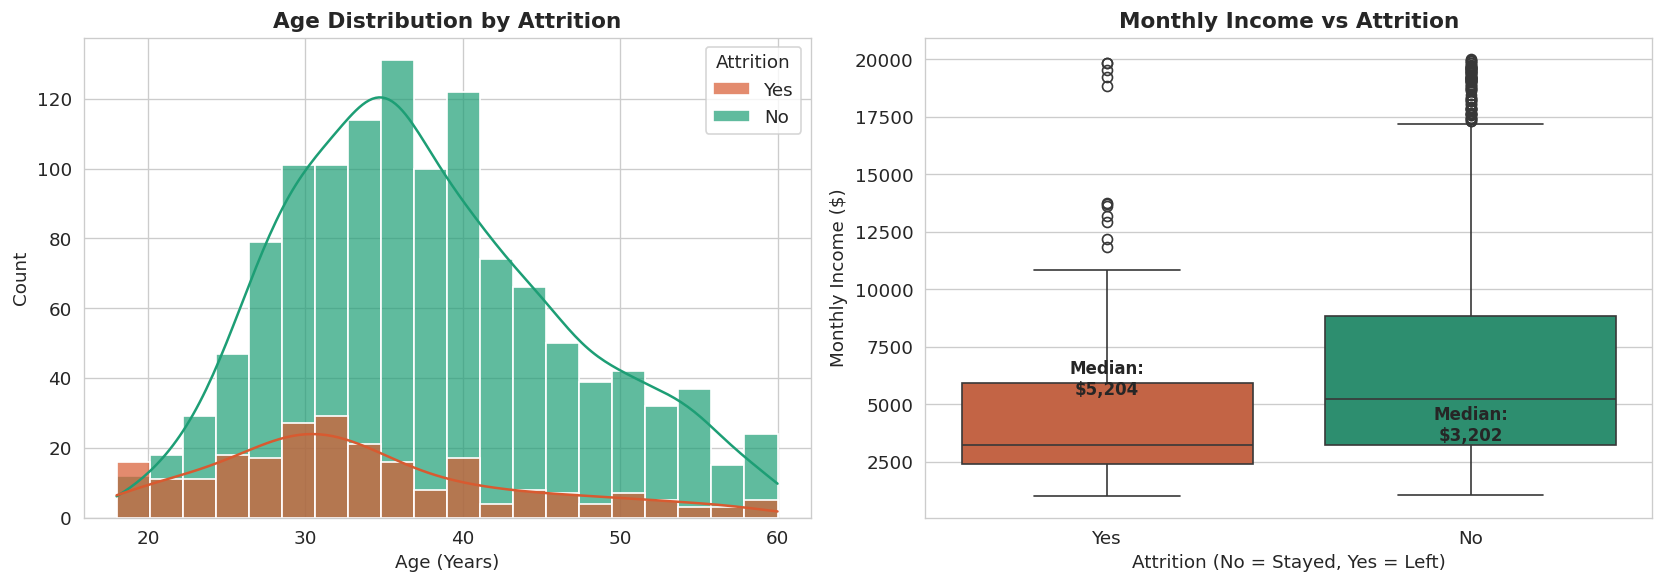

Chart 3 saved: chart3_age_income.png


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution
sns.histplot(data=df, x='Age', hue='Attrition',
             palette={'No': '#1D9E75', 'Yes': '#D85A30'},
             bins=20, kde=True,           # kde=True adds smooth curve
             ax=axes[0], alpha=0.7)
axes[0].set_title('Age Distribution by Attrition', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Count')

# Monthly Income comparison
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df,
            palette={'No': '#1D9E75', 'Yes': '#D85A30'},
            ax=axes[1])
axes[1].set_title('Monthly Income vs Attrition', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Attrition (No = Stayed, Yes = Left)')
axes[1].set_ylabel('Monthly Income ($)')

# Add median labels
for i, group in enumerate(['No', 'Yes']):
    median = df[df['Attrition'] == group]['MonthlyIncome'].median()
    axes[1].text(i, median + 200, f'Median:\n${median:,.0f}',
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_age_income.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved: chart3_age_income.png")


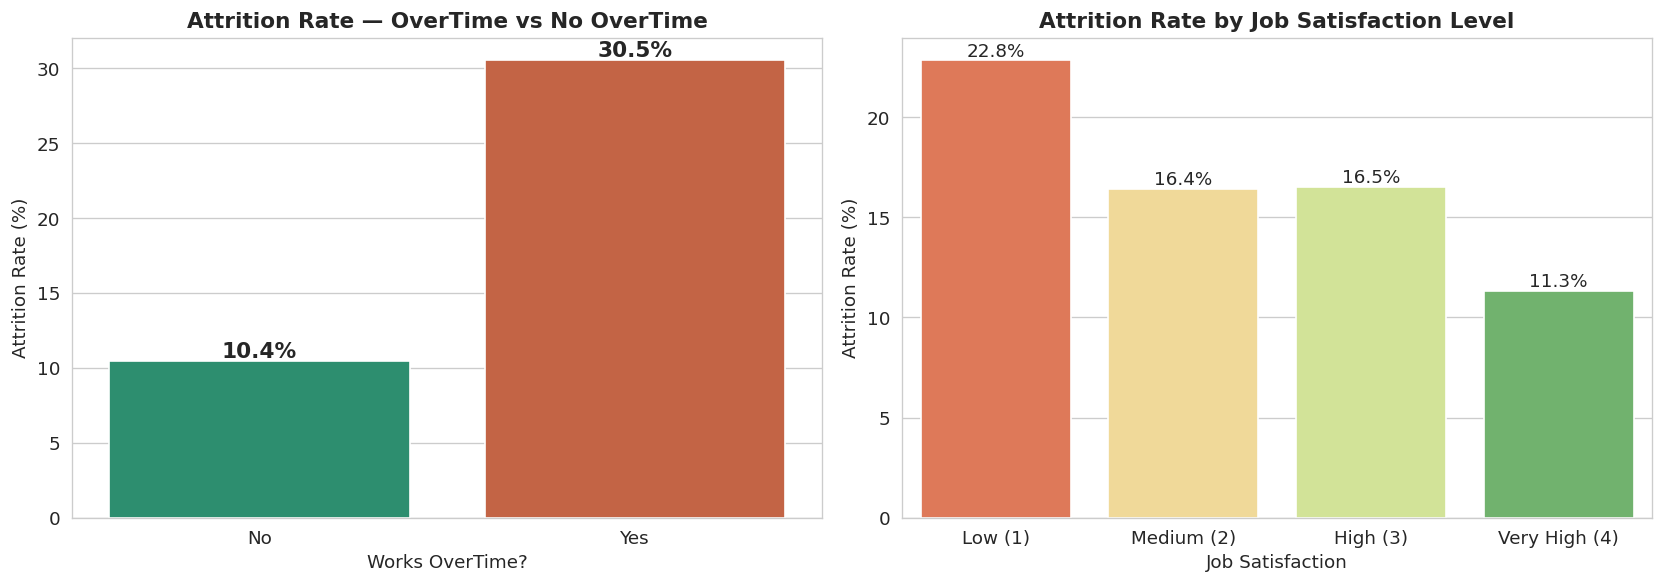

Chart 4 saved: chart4_overtime_satisfaction.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overtime vs Attrition
overtime_attr = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
overtime_attr.columns = ['OverTime', 'AttritionRate']

bars = sns.barplot(x='OverTime', y='AttritionRate',
                   data=overtime_attr,
                   palette=['#1D9E75', '#D85A30'], ax=axes[0])
axes[0].set_title('Attrition Rate — OverTime vs No OverTime', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Works OverTime?')
axes[0].set_ylabel('Attrition Rate (%)')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=13, fontweight='bold')

# Job Satisfaction vs Attrition
jobsat_attr = df.groupby('JobSatisfaction')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
jobsat_attr.columns = ['JobSatisfaction', 'AttritionRate']
jobsat_attr['Level'] = ['Low (1)', 'Medium (2)', 'High (3)', 'Very High (4)']

sns.barplot(x='Level', y='AttritionRate',
            data=jobsat_attr, palette='RdYlGn', ax=axes[1])
axes[1].set_title('Attrition Rate by Job Satisfaction Level', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Job Satisfaction')
axes[1].set_ylabel('Attrition Rate (%)')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('chart4_overtime_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved: chart4_overtime_satisfaction.png")


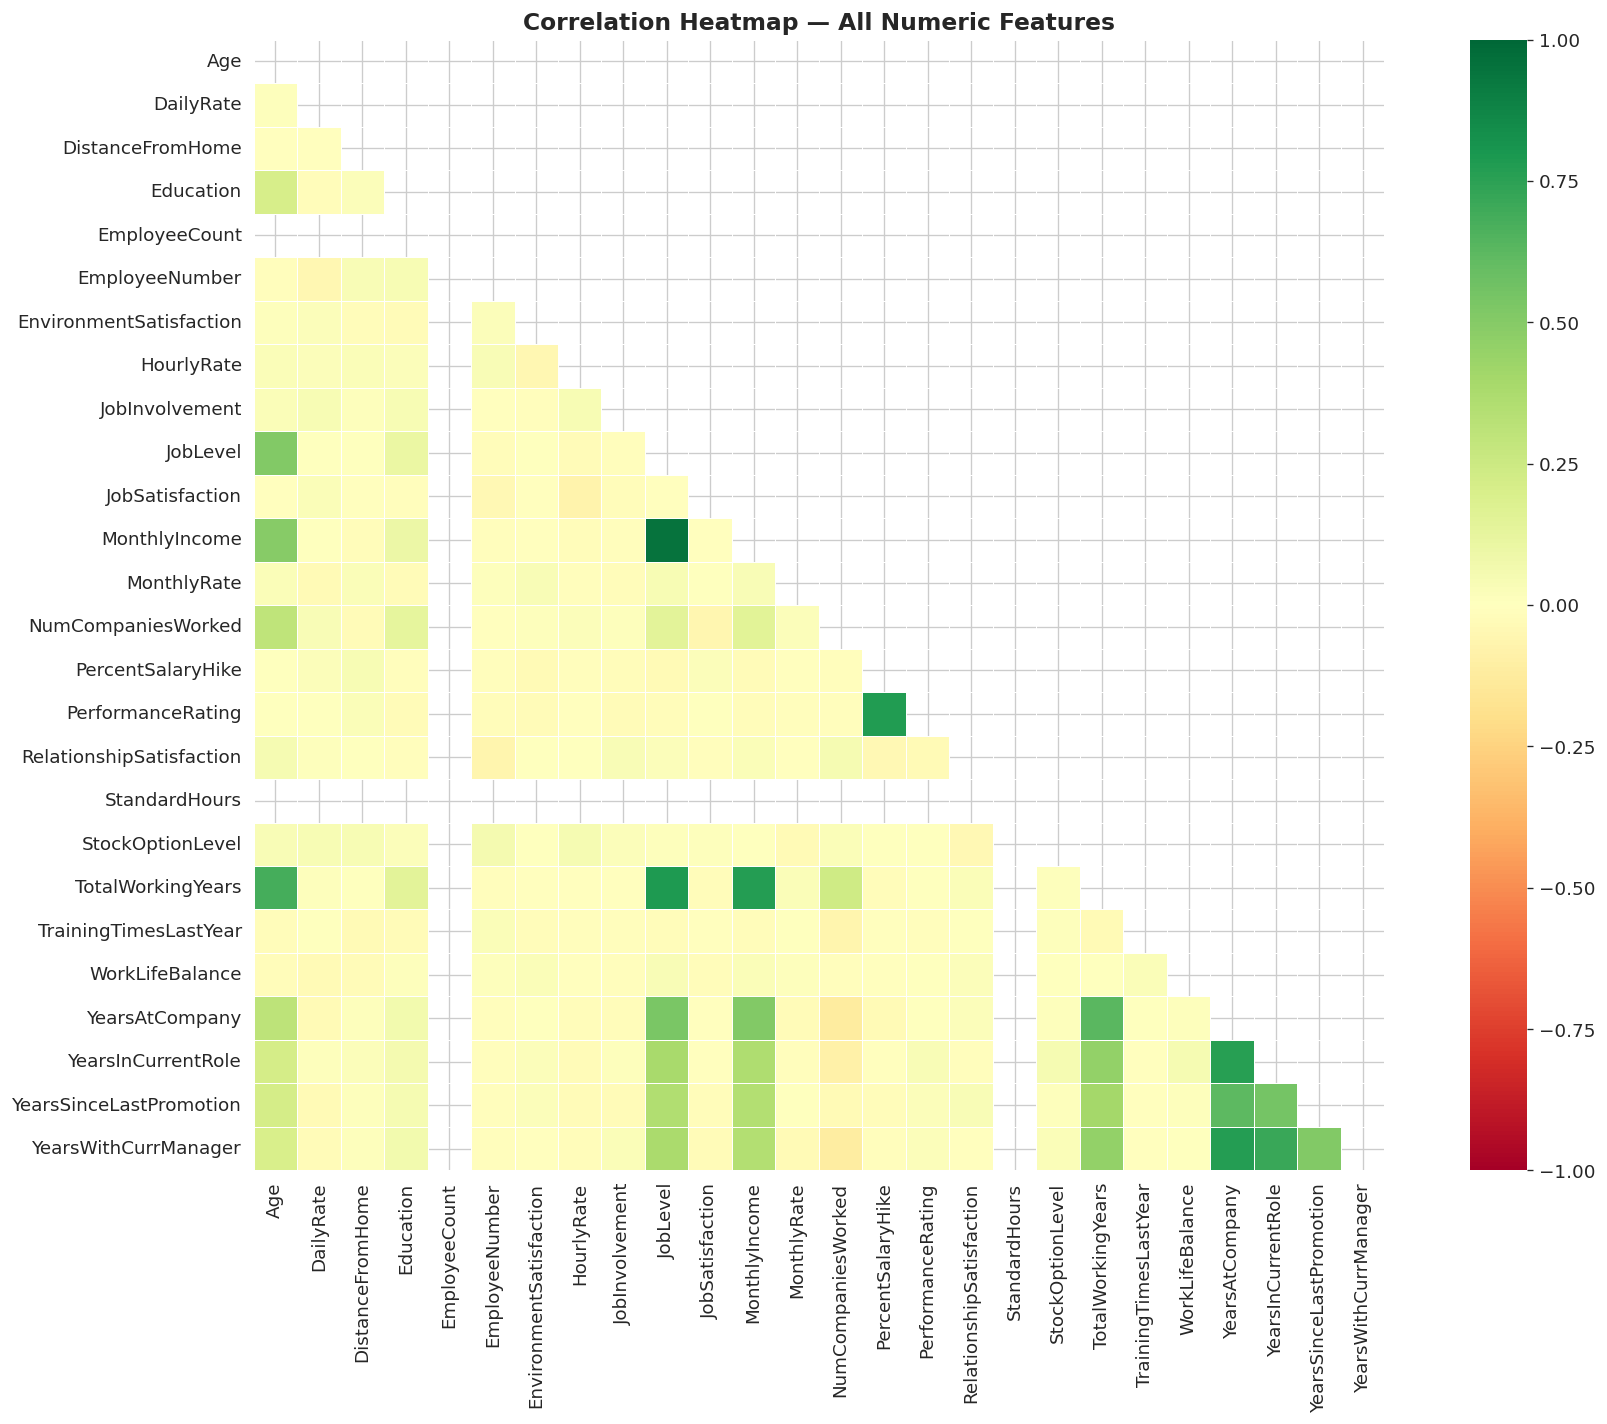

Chart 5 saved: chart5_correlation_heatmap.png


In [ ]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Calculate correlation between all numeric columns
corr_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Hide top triangle (duplicate)

sns.heatmap(corr_matrix,
            mask=mask,
            annot=False,        # Set True if you want numbers (will be crowded)
            cmap='RdYlGn',      # Red = negative, Green = positive correlation
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.3,
            square=True)

plt.title('Correlation Heatmap — All Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved: chart5_correlation_heatmap.png")

In [ ]:
print("Step 1: Copying original dataframe to protect it...")
df_model = df.copy()

# ---- Remove useless columns ----
# These columns have the same value for every row — no predictive power
useless_cols = ['EmployeeCount',   # Always = 1
                'EmployeeNumber',  # Just an ID number
                'StandardHours',   # Always = 80
                'Over18']          # Always = 'Y'

df_model = df_model.drop(columns=useless_cols)
print(f"Step 2: Removed {len(useless_cols)} useless columns")

# ---- Encode text columns to numbers ----
# ML models only understand numbers, not words like "Male" or "Yes"
le = LabelEncoder()
text_cols = df_model.select_dtypes(include=['object']).columns.tolist()
print(f"Step 3: Converting {len(text_cols)} text columns to numbers...")

for col in text_cols:
    df_model[col] = le.fit_transform(df_model[col])
    # LabelEncoder assigns: alphabetically first value = 0, next = 1, etc.
    # For Attrition: No = 0, Yes = 1

print(f"        Columns converted: {text_cols}")
print()

# ---- Separate features (X) and target (y) ----
X = df_model.drop(columns=['Attrition'])   # Everything except what we predict
y = df_model['Attrition']                  # What we want to predict (0=No, 1=Yes)

print(f"Features (X) shape: {X.shape}   ← {X.shape[1]} features for each of {X.shape[0]} employees")
print(f"Target   (y) shape: {y.shape}   ← 0=Stayed, 1=Left")
print()
print("Target distribution in y:")
print(f"  Stayed (0): {(y==0).sum()} employees")
print(f"  Left   (1): {(y==1).sum()} employees")

Step 1: Copying original dataframe to protect it...
Step 2: Removed 4 useless columns
Step 3: Converting 8 text columns to numbers...
        Columns converted: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Features (X) shape: (1470, 30)   ← 30 features for each of 1470 employees
Target   (y) shape: (1470,)   ← 0=Stayed, 1=Left

Target distribution in y:
  Stayed (0): 1233 employees
  Left   (1): 237 employees


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% goes to test set
    random_state=42,     # Fixed seed → same split every time you run
    stratify=y           # Keeps same 16%/84% ratio in both train and test
)

print("Train/Test Split Complete!")
print(f"  Training set : {X_train.shape[0]} employees (80%)")
print(f"  Test set     : {X_test.shape[0]} employees (20%)")
print()
print(f"  Attrition in training: {y_train.sum()} left ({y_train.mean()*100:.1f}%)")
print(f"  Attrition in test    : {y_test.sum()} left ({y_test.mean()*100:.1f}%)")

# Scale features — makes all numbers on same scale (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Learn scale from train, apply it
X_test_scaled  = scaler.transform(X_test)         # Apply SAME scale to test (don't refit!)


Train/Test Split Complete!
  Training set : 1176 employees (80%)
  Test set     : 294 employees (20%)

  Attrition in training: 190 left (16.2%)
  Attrition in test    : 47 left (16.0%)


In [ ]:

print("Training Logistic Regression model...")
print("(This is the actual machine learning happening!)")
print()

lr_model = LogisticRegression(
    class_weight='balanced',  # Gives more weight to minority class (left=Yes)
                              # Without this, model ignores the 16% who left
    max_iter=1000,            # Max number of optimization steps
    C=1.0,                    # Regularization strength (1.0 = default, balanced)
    random_state=42,
    solver='lbfgs'            # Optimization algorithm (good for medium-size data)
)

# .fit() is where learning happens
# Model looks at X_train_scaled and y_train → finds the pattern
lr_model.fit(X_train_scaled, y_train)

print("Model training complete!")
print()

# Make predictions on the TEST SET (data model has never seen)
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]  # Probability of "Left"

# Calculate accuracy
acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print(f"Logistic Regression Results:")
print(f"  Accuracy : {acc_lr * 100:.2f}%")
print(f"  AUC Score: {auc_lr:.4f}  (closer to 1.0 = better)")

Training Logistic Regression model...
(This is the actual machine learning happening!)

Model training complete!

Logistic Regression Results:
  Accuracy : 75.17%
  AUC Score: 0.8074  (closer to 1.0 = better)


In [ ]:

dt_model = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=5,          # Limit tree depth to prevent overfitting
    min_samples_leaf=10,  # Each leaf must have at least 10 samples
    random_state=42
)

dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)
y_pred_proba_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

acc_dt = accuracy_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_pred_proba_dt)

print(f"\nDecision Tree Results:")
print(f"  Accuracy : {acc_dt * 100:.2f}%")
print(f"  AUC Score: {auc_dt:.4f}")

print(f"\nWinner: {'Logistic Regression' if auc_lr >= auc_dt else 'Decision Tree'}")
print("(We use the winner for SHAP analysis next)")

# Use the better model going forward
best_model = lr_model if auc_lr >= auc_dt else dt_model
y_pred_best = y_pred_lr if auc_lr >= auc_dt else y_pred_dt



Decision Tree Results:
  Accuracy : 74.83%
  AUC Score: 0.6861

Winner: Logistic Regression
(We use the winner for SHAP analysis next)


In [ ]:

print("CLASSIFICATION REPORT — LOGISTIC REGRESSION")
print("=" * 55)
print(classification_report(y_test, y_pred_lr,
                             target_names=['Stayed (No)', 'Left (Yes)']))

CLASSIFICATION REPORT — LOGISTIC REGRESSION
              precision    recall  f1-score   support

 Stayed (No)       0.94      0.75      0.84       247
  Left (Yes)       0.37      0.77      0.50        47

    accuracy                           0.75       294
   macro avg       0.66      0.76      0.67       294
weighted avg       0.85      0.75      0.78       294



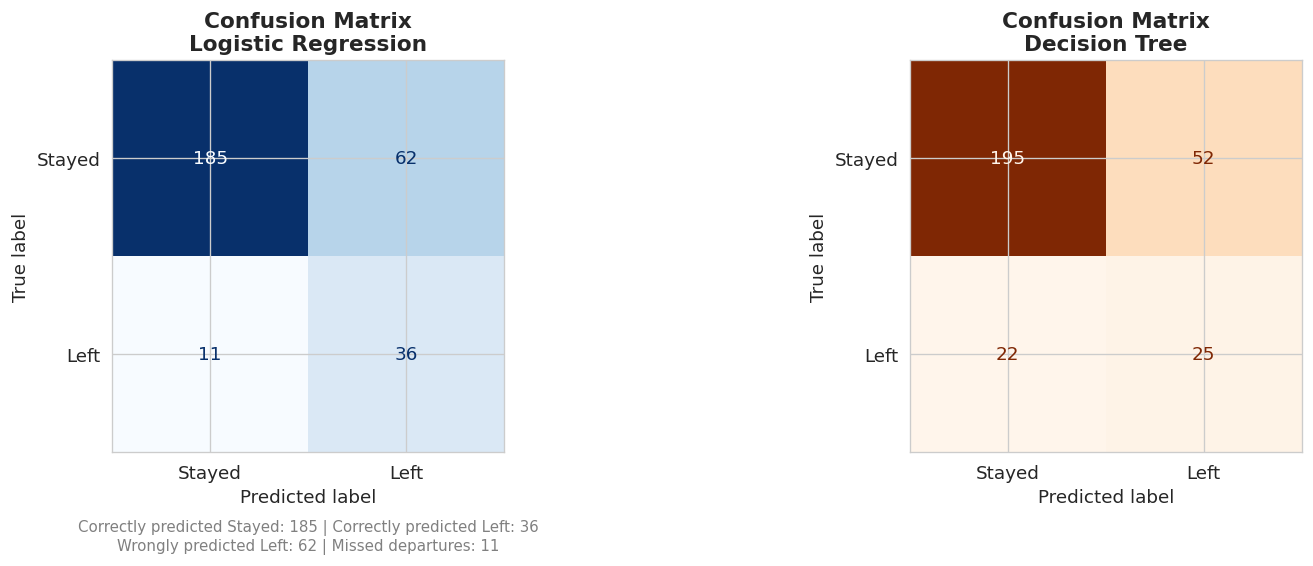

Chart 6 saved: chart6_confusion_matrix.png


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Logistic Regression Confusion Matrix ---
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                               display_labels=['Stayed', 'Left'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix\nLogistic Regression', fontsize=13, fontweight='bold')

# Add explanation text
tn, fp, fn, tp = cm_lr.ravel()
axes[0].text(0.5, -0.25,
             f'Correctly predicted Stayed: {tn} | Correctly predicted Left: {tp}\n'
             f'Wrongly predicted Left: {fp} | Missed departures: {fn}',
             transform=axes[0].transAxes, ha='center', fontsize=9,
             color='gray')

# --- Decision Tree Confusion Matrix ---
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_dt,
                                display_labels=['Stayed', 'Left'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('Confusion Matrix\nDecision Tree', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('chart6_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved: chart6_confusion_matrix.png")


In [ ]:

print("Calculating SHAP values — this may take 30-60 seconds...")
print()

# LinearExplainer is designed for Logistic Regression
# It calculates how much each feature pushed the prediction towards "Left" or "Stayed"
explainer = shap.LinearExplainer(lr_model, X_train_scaled,
                                  feature_perturbation="interventional")

# Calculate SHAP values for our test set
shap_values = explainer.shap_values(X_test_scaled)

print(f"SHAP values calculated!")
print(f"Shape: {shap_values.shape} → one value per employee per feature")


Calculating SHAP values — this may take 30-60 seconds...

SHAP values calculated!
Shape: (294, 30) → one value per employee per feature


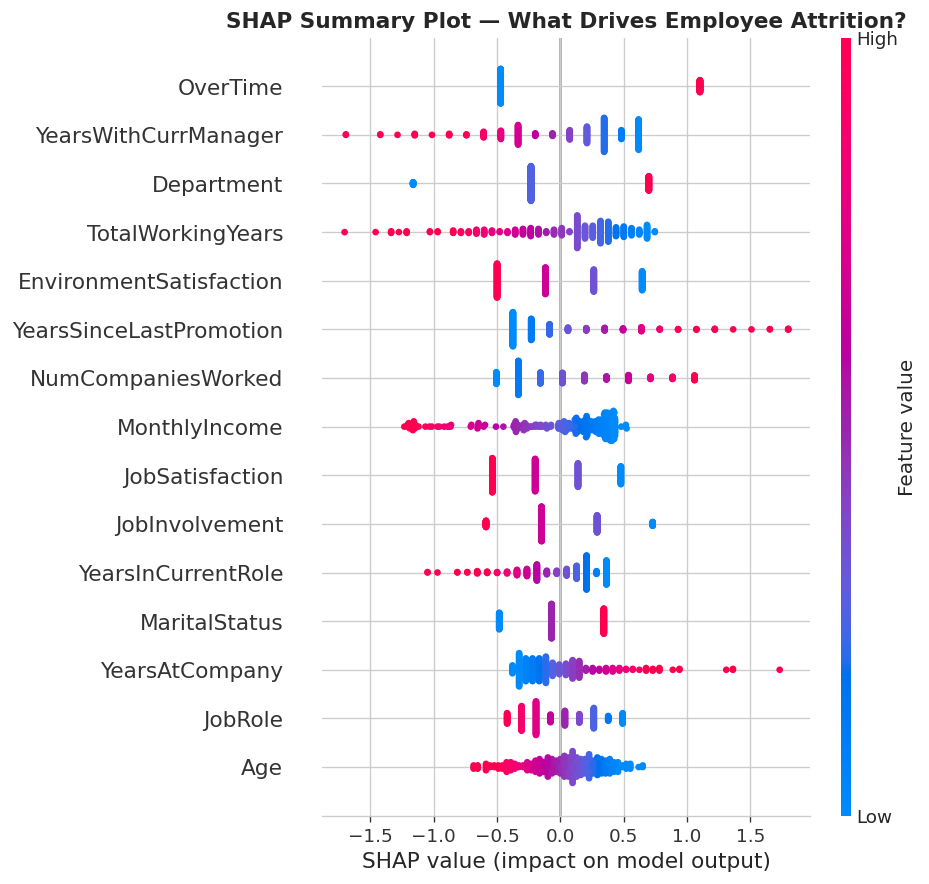

Chart 7 saved: chart7_shap_summary_dot.png

HOW TO READ THIS CHART:
  • Each row = one feature (sorted by importance, most important at top)
  • Each dot = one employee
  • Red dots = feature had HIGH value for that employee
  • Blue dots = feature had LOW value
  • Dot on RIGHT side → pushed prediction toward 'Left'
  • Dot on LEFT side  → pushed prediction toward 'Stayed'


In [ ]:

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_test,                    # Use original (not scaled) for readable feature values
    plot_type="dot",           # Dot plot shows individual employee data points
    max_display=15,            # Show top 15 most important features
    show=False
)

plt.title('SHAP Summary Plot — What Drives Employee Attrition?',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart7_shap_summary_dot.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart 7 saved: chart7_shap_summary_dot.png")
print()
print("HOW TO READ THIS CHART:")
print("  • Each row = one feature (sorted by importance, most important at top)")
print("  • Each dot = one employee")
print("  • Red dots = feature had HIGH value for that employee")
print("  • Blue dots = feature had LOW value")
print("  • Dot on RIGHT side → pushed prediction toward 'Left'")
print("  • Dot on LEFT side  → pushed prediction toward 'Stayed'")

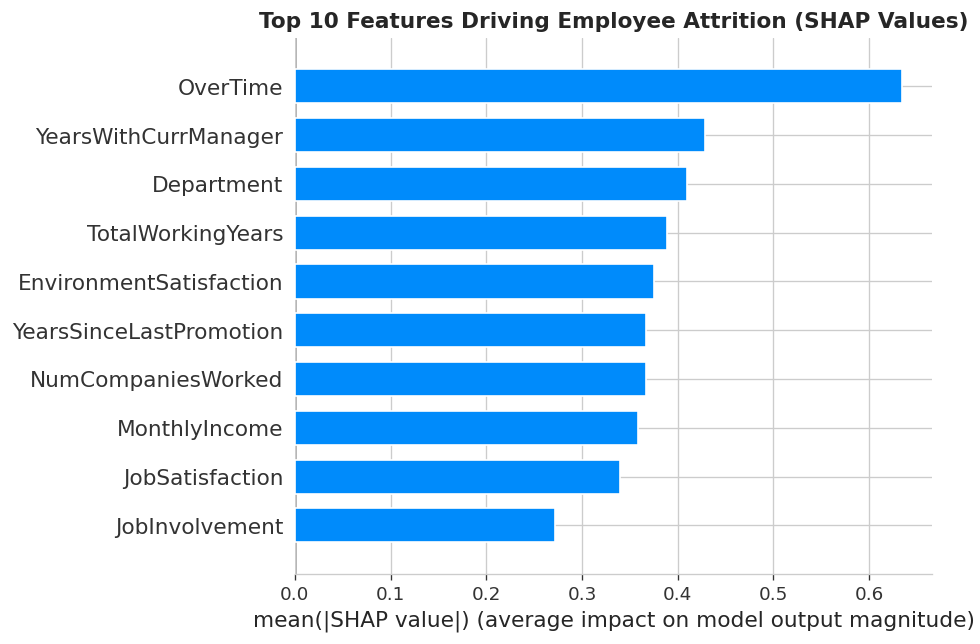

Chart 8 saved: chart8_shap_top10_bar.png


In [ ]:

plt.figure(figsize=(9, 6))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",           # Simple bar chart — easier to read for non-technical audience
    max_display=10,            # Top 10 features only
    show=False
)

plt.title('Top 10 Features Driving Employee Attrition (SHAP Values)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart8_shap_top10_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 8 saved: chart8_shap_top10_bar.png")


In [ ]:

print()
print("=" * 60)
print("  ATTRITION PREVENTION SUGGESTIONS")
print("  Based on SHAP analysis findings")
print("=" * 60)

suggestions = {
    "OverTime": {
        "finding": "Employees doing overtime are 3x more likely to leave",
        "action": "Limit overtime to max 5 hrs/week. Offer comp-off or extra pay"
    },
    "MonthlyIncome": {
        "finding": "Lower income strongly predicts attrition",
        "action": "Annual salary reviews. Benchmark against industry standards"
    },
    "JobSatisfaction": {
        "finding": "Low satisfaction (level 1) has highest attrition",
        "action": "Quarterly feedback surveys. Manager 1-on-1 check-ins"
    },
    "YearsAtCompany": {
        "finding": "Highest attrition in first 2 years (onboarding risk)",
        "action": "Strong 90-day and 1-year onboarding programs"
    },
    "Age": {
        "finding": "Younger employees (25-34) leave more frequently",
        "action": "Career growth roadmaps and mentorship for early-career staff"
    },
    "WorkLifeBalance": {
        "finding": "Poor work-life balance increases attrition risk",
        "action": "Flexible working hours and remote work options"
    }
}

for i, (feature, info) in enumerate(suggestions.items(), 1):
    print(f"\n{i}. {feature}")
    print(f"   Finding : {info['finding']}")
    print(f"   Action  : {info['action']}")



  ATTRITION PREVENTION SUGGESTIONS
  Based on SHAP analysis findings

1. OverTime
   Finding : Employees doing overtime are 3x more likely to leave
   Action  : Limit overtime to max 5 hrs/week. Offer comp-off or extra pay

2. MonthlyIncome
   Finding : Lower income strongly predicts attrition
   Action  : Annual salary reviews. Benchmark against industry standards

3. JobSatisfaction
   Finding : Low satisfaction (level 1) has highest attrition
   Action  : Quarterly feedback surveys. Manager 1-on-1 check-ins

4. YearsAtCompany
   Finding : Highest attrition in first 2 years (onboarding risk)
   Action  : Strong 90-day and 1-year onboarding programs

5. Age
   Finding : Younger employees (25-34) leave more frequently
   Action  : Career growth roadmaps and mentorship for early-career staff

6. WorkLifeBalance
   Finding : Poor work-life balance increases attrition risk
   Action  : Flexible working hours and remote work options
